# 5.5.1 熵与互信息的离散定义

## 学习目标与先修知识

能推导离散熵（entropy）、条件熵（conditional entropy）与互信息（mutual information），处理零概率（probability）和对数单位；用独立、复制、翻转通道检查信息含义及因果边界。

先修：5.3 的联合和条件概率（conditional probability），5.2 的期望（expectation），第 2 篇的对数。 [复习上一节](../04-随机过程与马尔可夫模型/03-随机游走中的漂移与扩散.ipynb)。

## 具体问题

知道这个读数后，对隐藏状态（state）的不确定性平均能减少多少？本章的“测量价值”仅指在给定概率模型（model）和观测（observation）编码下提供的信息量，不等同于临床效用、决策效用、经济价值、因果作用或干预收益。

一个读数本身很随机，就一定对细胞状态（state）有帮助吗？一台总把 0 与 1 翻转的仪器，是否必定完全没有信息？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
tables={'copy':[[.5,0],[0,.5]],'independent':[[.25,.25],[.25,.25]],'flip':[[0,.5],[.5,0]]}
for name,table in tables.items():print(name,np.array(table))

copy [[0.5 0. ]
 [0.  0.5]]
independent [[0.25 0.25]
 [0.25 0.25]]
flip [[0.  0.5]
 [0.5 0. ]]


## 模型假设

X 为公平二值细胞标签，观测（observation）通道以错误概率 ε 独立翻转标签；联合表行表示 X，列表示 Y，四格为 (1−ε)/2、ε/2、ε/2、(1−ε)/2。本节精确概率求和；频数输入（input）时只先归一化，不额外平滑。离散标签不等同于热力学状态。

## 数学解释与推导

概率 p>0 的事件（event）的信息量定义为 −log₂p，单位 bit；确定事件为零，两个独立事件的联合概率（joint probability）相乘使信息量相加。对随机变量（random variable）取期望得到熵
$$H(X)=-\sum_x p(x)\log_2p(x),\qquad0\log_20:=0.$$
零概率事件不会被抽到，其加权极限（limit）贡献为零；不能在程序中直接求 log(0)。公平二值的熵为 1 bit，确定标签为 0 bit。

联合熵（joint entropy） H(X,Y) 使用联合概率；条件熵 H(X|Y)=Σᵧp(y)H(X|Y=y)，零边缘概率列不贡献。由 p(x,y)=p(y)p(x|y) 展开对数，H(X,Y)=H(Y)+H(X|Y)。观察 Y 对 X 的平均不确定性减少定义为
$$I(X;Y)=H(X)-H(X|Y)=\sum_{x,y:p(x,y)>0}p(x,y)\log_2\frac{p(x,y)}{p(x)p(y)}.$$
它关于 X、Y 对称。非负性（nonnegativity）可由 log t≤t−1 推出：以联合 p、边缘乘积 q 为例，在 p>0 的格上求和，有 $-I\ln2=\sum_{p>0}p\ln(q/p)\le\sum_{p>0}(q-p)\le0$；最后一步用到这些格上的 q 之和不超过 1，故 I≥0；独立时每个比值为 1，I=0。有限离散情形 I≤min(H(X),H(Y))，来自条件熵非负。

二值翻转通道在公平输入时 Y 仍公平；给定 Y 后 X 的错误概率是 ε，所以 $I=1-h_2(\varepsilon)$，其中 $h_2(e)=-e\log_2e-(1-e)\log_2(1-e)$。ε=1 是已知可逆翻转，仍保留 1 bit；ε=0.5 才完全独立。

以 e 为对数底得到 nat，需乘 ln2 才由 bit 转为 nat。互信息对称且可能来自共同原因，不能仅由正值判断因果方向或干预效果；也不自动等于物理热力学熵。

## 核心实现

把公式中的量和顺序写成可检查的计算。

In [3]:
def information(counts):
    import math
    total = sum(map(sum, counts))
    joint = [[c/total for c in row] for row in counts]
    px = list(map(sum,joint))
    py = [sum(row[j] for row in joint) for j in range(len(joint[0]))]
    hx = -sum(p*math.log2(p) for p in px if p>0)
    hy = -sum(p*math.log2(p) for p in py if p>0)
    mi = sum(p*math.log2(p/(px[i]*py[j])) for i,row in enumerate(joint) for j,p in enumerate(row) if p>0)
    return hx, hy, mi

## 对照实验

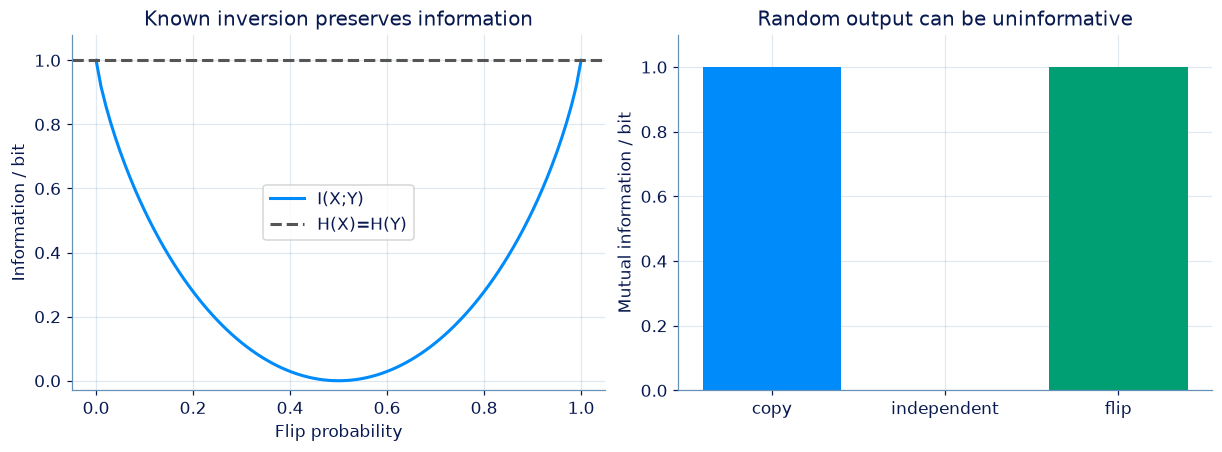

| 通道 | H(X) / bit | H(Y) / bit | I / bit |
| --- | --- | --- | --- |
| copy | 1 | 1 | 1 |
| independent | 1 | 1 | 0 |
| flip | 1 | 1 | 1 |

In [4]:
errors=np.linspace(0,1,101)
infos=np.array([information([[(1-e)/2,e/2],[e/2,(1-e)/2]]) for e in errors])
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(errors,infos[:,2],color=BLUE,label='I(X;Y)');axes[0].axhline(1,color=GRAY,ls='--',label='H(X)=H(Y)')
axes[0].set(xlabel='Flip probability',ylabel='Information / bit',ylim=(-.03,1.08),title='Known inversion preserves information');axes[0].legend()
for j,(name,table) in enumerate(tables.items()):
    hx,hy,mi=information(table);axes[1].bar(j,mi,color=[BLUE,PINK,GREEN][j])
axes[1].set(xticks=[0,1,2],xticklabels=list(tables),ylabel='Mutual information / bit',ylim=(0,1.1),title='Random output can be uninformative')
plt.show()
display(Markdown(show_table(['通道','H(X) / bit','H(Y) / bit','I / bit'],[(name,*information(table)) for name,table in tables.items()])))

## 结果解释

三个通道的输出（output）熵都为 1 bit，但独立通道的互信息为零。标签是否相同不是信息量的定义；知道翻转规则即可恢复原标签。所有数值来自指定概率模型（model），不能直接推广到未知真实数据。

### 独立核对

用通道条件熵的单变量式对照二维联合求和，再检查极端分布（distribution）和信息边界。

In [5]:
np.testing.assert_allclose(information([[2,0],[0,2]]),[1,1,1])
np.testing.assert_allclose(information([[1,1],[1,1]]),[1,1,0])
np.testing.assert_allclose(information([[0,0],[0,4]]),[0,0,0])
def binary_entropy(e):
    return sum(-p*math.log2(p) for p in [e,1-e] if p>0)
np.testing.assert_allclose(infos[:,2],[1-binary_entropy(e) for e in errors],atol=1e-12)
assert np.all(infos[:,2]>=-1e-12) and np.all(infos[:,2]<=1+1e-12)
print('复制、独立、翻转、零行与二元条件熵的独立表达一致。')

复制、独立、翻转、零行与二元条件熵的独立表达一致。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：联合计数包含多少信息

给定细胞状态（state） X 与二值或多值读数 Y 的联合计数。用明确的以 2 为底的插件估计（plug-in estimator）计算边缘熵（entropy）和互信息（mutual information）。

**函数与代码模板**

```python
def solve(
    counts: list[list[int]],
) -> tuple[float, float, float]:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `counts` | `list[list[int]]` | 行表示 X，列表示 Y 的联合频数表。 | 次 |

**返回值**

按以下顺序返回元组：(entropy_x, entropy_y, mutual_information)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `entropy_x` | `float` | X 的离散插件熵。 | bit |
| `entropy_y` | `float` | Y 的离散插件熵。 | bit |
| `mutual_information` | `float` | X、Y 的插件互信息。 | bit |

**计算规则**

先除以总频数得到 p[i,j]，按行列求边缘概率（probability）；H(X)=−ΣpX log2(pX)，H(Y) 同理；I=Σp[i,j] log2(p[i,j]/(pX[i]*pY[j]))。零概率项贡献 0，不给零频数加伪计数。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 矩形表 1—8 行、1—8 列；每项整数 0—10000；总频数>0。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| counts | 行表示 X，列表示 Y 的联合频数表。 | [[2, 0], [0, 2]] | 次 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
counts = [[2, 0], [0, 2]]

result = solve(counts)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| entropy_x | X 的离散插件熵。 | 1 | bit |
| entropy_y | Y 的离散插件熵。 | 1 | bit |
| mutual_information | X、Y 的插件互信息。 | 1 | bit |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.0, 1.0, 1.0)
```

**样例解释**

X、Y 各一半，且标签完全一致：H(X)=H(Y)=I=1 bit。这不表示存在 1 bit 的因果作用。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：联合计数包含多少信息](http://127.0.0.1:8000/chapters/05-05-%E7%86%B5%E3%80%81%E4%BA%92%E4%BF%A1%E6%81%AF%E4%B8%8E%E6%B5%8B%E9%87%8F%E4%BB%B7%E5%80%BC/practice/?question=p05-information)

### 第 2 题 · 单项选择题：公平二值状态的熵

X 为公平二值状态（state）。通道一精确复制 X，通道二输出（output）与 X 独立的公平二值 Y。互信息（mutual information）依次是多少？

- **A.** 1 bit、1 bit。
- **B.** 0 bit、1 bit。
- **C.** 0 bit、0 bit。
- **D.** 1 bit、0 bit。

[作答：公平二值状态的熵](http://127.0.0.1:8000/chapters/05-05-%E7%86%B5%E3%80%81%E4%BA%92%E4%BF%A1%E6%81%AF%E4%B8%8E%E6%B5%8B%E9%87%8F%E4%BB%B7%E5%80%BC/practice/?question=p05-entropy)

### 第 3 题 · 多项选择题：互信息减少的是什么

有限离散变量的 I(X;Y)=H(X)−H(X|Y)。哪些正确？

- **A.** I(X;Y)=I(Y;X)。
- **B.** 把对数底改为 e 后数值单位变为 nat。
- **C.** 它是观察 Y 后对 X 的平均不确定性减少量。
- **D.** 它一定等于 Y 的熵（entropy）。

[作答：互信息减少的是什么](http://127.0.0.1:8000/chapters/05-05-%E7%86%B5%E3%80%81%E4%BA%92%E4%BF%A1%E6%81%AF%E4%B8%8E%E6%B5%8B%E9%87%8F%E4%BB%B7%E5%80%BC/practice/?question=p05-conditional-entropy)

### 第 4 题 · 单项选择题：总是翻转标签会失去信息吗

X 公平二值，Y=1−X，映射规则已知。哪项正确？

- **A.** 只有正相关才有互信息（mutual information）。
- **B.** I=0，因为标签从不相等。
- **C.** I=1 bit，因为由 Y 可唯一恢复 X。
- **D.** I=−1 bit。

[作答：总是翻转标签会失去信息吗](http://127.0.0.1:8000/chapters/05-05-%E7%86%B5%E3%80%81%E4%BA%92%E4%BF%A1%E6%81%AF%E4%B8%8E%E6%B5%8B%E9%87%8F%E4%BB%B7%E5%80%BC/practice/?question=p05-channel-flip)

### 第 5 题 · 多项选择题：统计信息是否等于作用方向

细胞标记 X 与 Y 的互信息（mutual information）为正。哪些判断合适？

- **A.** 可以由共同原因造成。
- **B.** 已证明 X 导致 Y。
- **C.** 指标对称，不能仅由其数值确定因果方向。
- **D.** 等同于热力学熵（entropy）增加。

[作答：统计信息是否等于作用方向](http://127.0.0.1:8000/chapters/05-05-%E7%86%B5%E3%80%81%E4%BA%92%E4%BF%A1%E6%81%AF%E4%B8%8E%E6%B5%8B%E9%87%8F%E4%BB%B7%E5%80%BC/practice/?question=p05-information-scope)

**进一步阅读**

[MIT 6.441 讲义](https://ocw.mit.edu/courses/6-441-information-theory-spring-2016/pages/lecture-notes/)，第 1 章 §1.1 熵、第 2 章 §2.3 互信息、第 3 章 §3.1 数据处理；本节只用有限离散情形，完整测度论不作为先修。